### Import packages

In [68]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.metrics import silhouette_score
import plotly.express as px 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

### Load the dataset

the two methods to find the best k

1. Elbow method → plot inertia vs K → look for the bend
2. Silhouette score → measure cluster quality → higher is better

Load the Dataset which is encoded and not scaled

In [40]:
df = pd.read_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_4-global_mobile_reviews\data\processed_data\Mobile_Reviews_Sentiment_after_encoded_and_before_scaling.csv")
print(df.head(5))

df_1 = df.copy()

print(df_1.columns.tolist())

print(df.shape)


   age  price_usd  rating  verified_purchase  battery_life_rating  \
0   45     337.31       2                  1                    1   
1   18     307.78       4                  1                    3   
2   27     864.53       4                  1                    3   
3   19     660.94       3                  0                    1   
4   38     792.13       3                  1                    3   

   camera_rating  performance_rating  design_rating  display_rating  \
0              1                   3              2               1   
1              2                   4              3               2   
2              5                   3              2               4   
3              3                   2              1               2   
4              3                   2              2               1   

   helpful_votes  ...  country_USA  language_English  language_German  \
0              1  ...            0                 0                0   
1           

Using Normalizer

k-means - Elbow method:

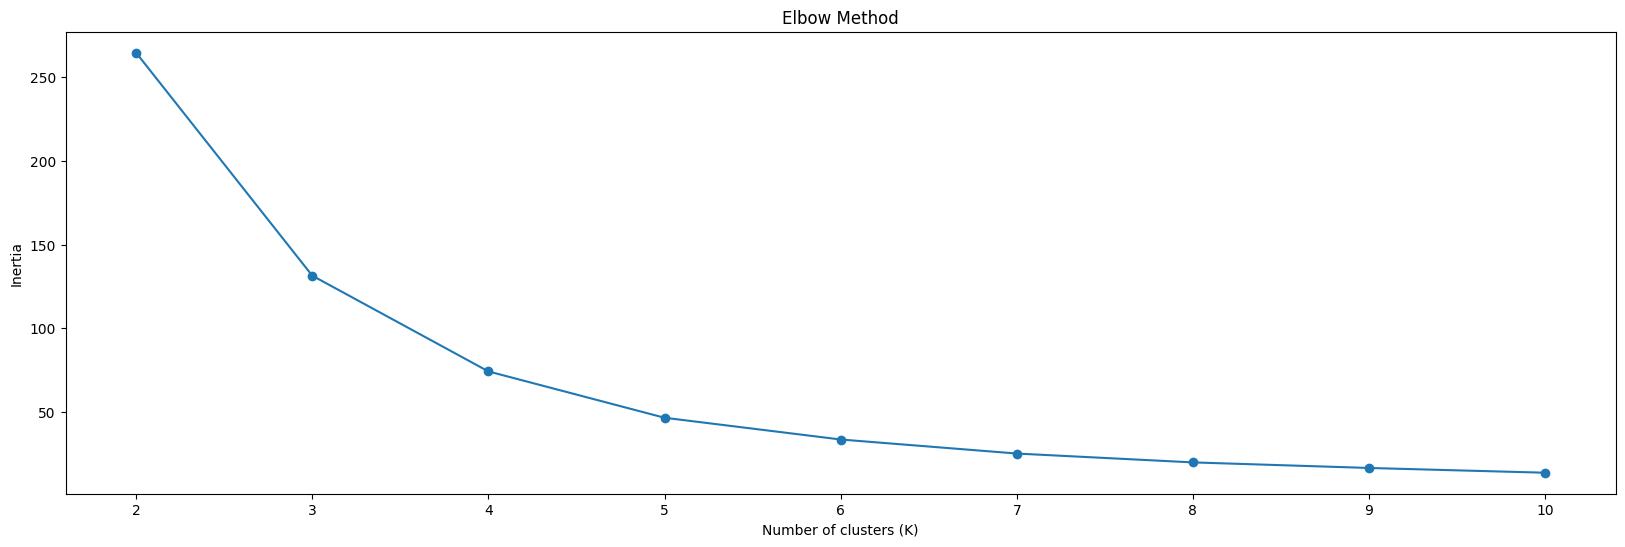

In [41]:
normal = Normalizer()
df_1_normal = normal.fit_transform(df_1)

Inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_1_normal)
    Inertia.append(kmeans.inertia_)  

plt.figure(figsize=(20, 6))
plt.plot(K_range, Inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

silhoutte score:

K=2 done, score=0.6014
K=3 done, score=0.5381
K=4 done, score=0.5353
K=5 done, score=0.5391
K=6 done, score=0.5193
K=7 done, score=0.5121
K=8 done, score=0.5047
K=9 done, score=0.4859
K=10 done, score=0.4783


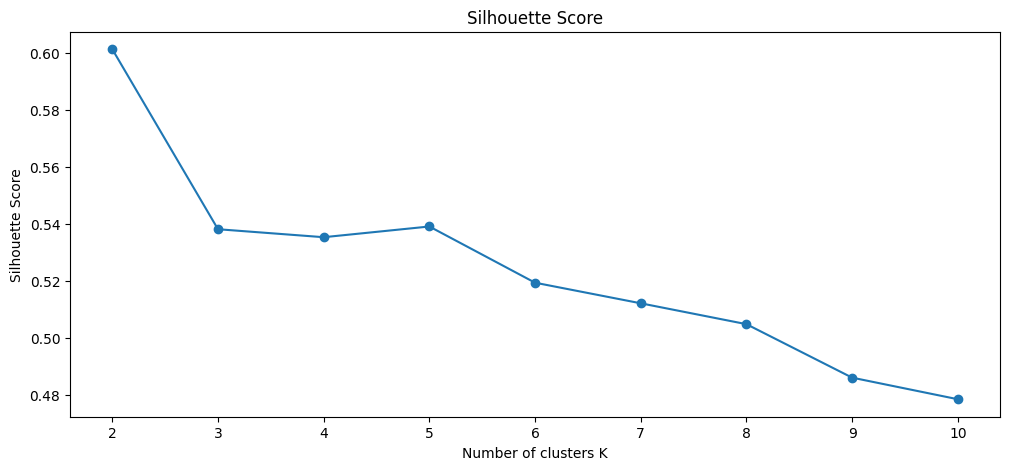

In [42]:
silhouette_scores = []
K_range = range(2, 11)

np.random.seed(42)
sample_size = min(5000, len(df_1_normal))
sample_idx = np.random.choice(len(df_1_normal), sample_size,replace=False)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_1_normal)
    score = silhouette_score(df_1_normal[sample_idx], labels[sample_idx])
    silhouette_scores.append(score)
    print(f'K={k} done, score={score:.4f}')

plt.figure(figsize=(12, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette Score')
plt.show()



Higher silhouette -> better clustering, 

K=2  , score=0.6014 -> highest, 

K=3  , score=0.5381,

K=4  , score=0.5353,

K=5  , score=0.5391,

K=6  , score=0.5193,

K=7  , score=0.5121,

K=8  , score=0.5047,

K=9  , score=0.4859,

K=10 , score=0.4783,

So optimal K = 2!

In [43]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_1_normal)

df_1['cluster'] = labels

profile_1 = df_1.groupby('cluster')[['price_usd','rating', 'battery_life_rating','camera_rating', 
                            'performance_rating','design_rating','display_rating','age']].mean().round(2)
print(profile_1)

         price_usd  rating  battery_life_rating  camera_rating  \
cluster                                                          
0          1294.81    3.11                 2.71           2.72   
1           515.99    3.10                 2.72           2.71   
2           721.34    3.10                 2.72           2.71   
3           308.18    3.10                 2.71           2.72   
4           968.35    3.11                 2.74           2.73   

         performance_rating  design_rating  display_rating    age  
cluster                                                            
0                      2.71           2.72            2.72  30.13  
1                      2.73           2.70            2.72  30.04  
2                      2.70           2.72            2.72  30.08  
3                      2.73           2.71            2.72  30.03  
4                      2.72           2.72            2.73  30.14  


In [44]:
fig = px.bar(
                profile_1,
                barmode='group',        
                title='Cluster Profiles'
)
fig.update_layout(
                xaxis_title='Cluster',
                yaxis_title='Average Score',
                legend_title='Features',
                width=850,
                height=500,
                title_x = 0.5
)
fig.show()

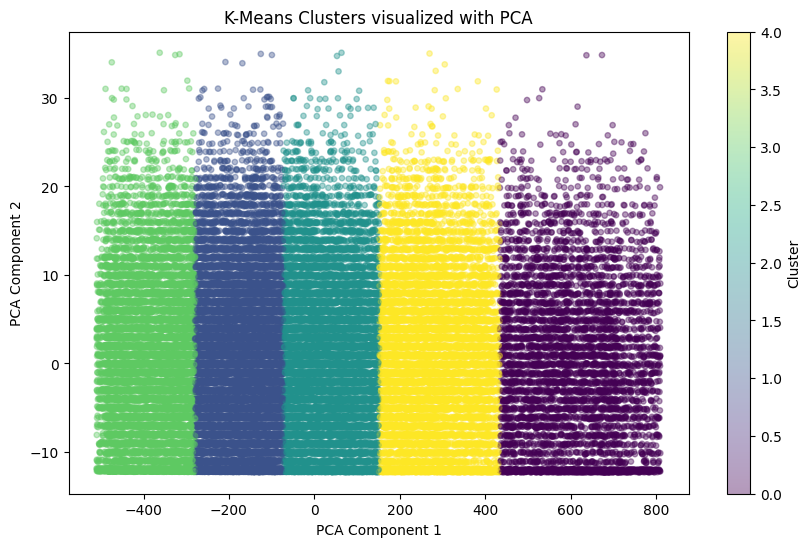

(50000, 2)
(50000, 60)


In [48]:
# Reduce to 2 dimensions


pca = PCA(n_components=2)
df_1_pca = pca.fit_transform(df_1)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_1_pca[:, 0], df_1_pca[:, 1], 
                      c=df_1['cluster'], 
                    #   cmap='tab10',
                      alpha=0.4,
                      s=15)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

print(df_1_pca.shape)
print(df.shape)

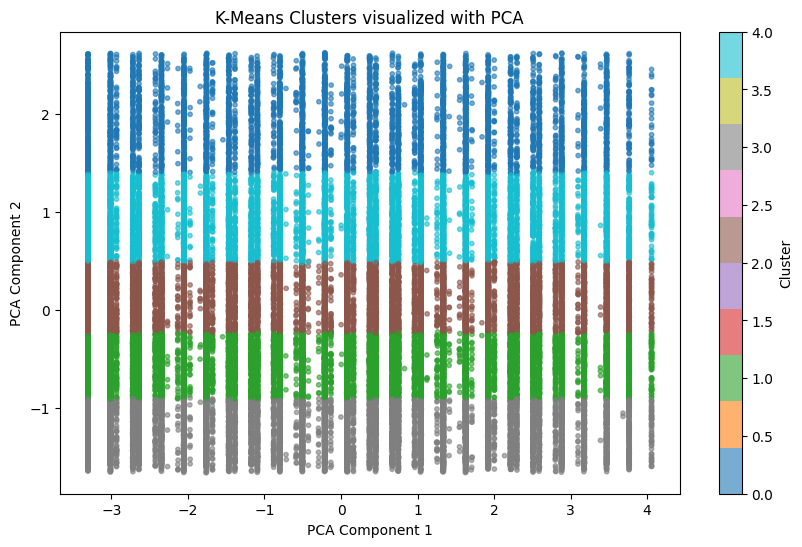

In [56]:
key_cols = ['rating', 'price_usd', 'battery_life_rating', 
            'camera_rating', 'performance_rating', 
            'design_rating', 'display_rating']


# Scale only these columns
scaler = StandardScaler()
df_numerics = scaler.fit_transform(df[key_cols])

# Reduce to 2 dimensions
pca = PCA(n_components=2)
df_1_pca = pca.fit_transform(df_numerics)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_1_pca[:, 0], df_1_pca[:, 1], 
                      c=df_1['cluster'], 
                      cmap='tab10',
                      alpha=0.6,
                      s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

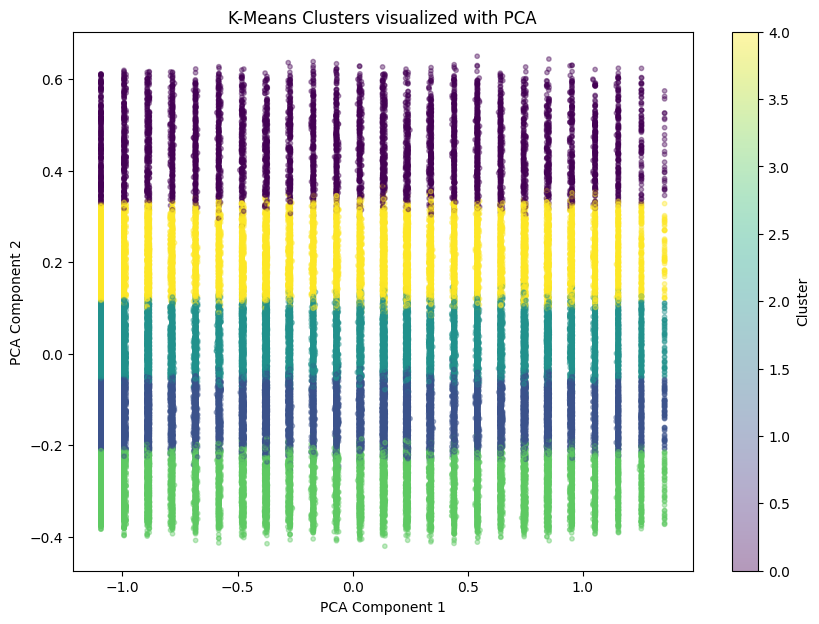

In [54]:
# Use only the key numeric columns
key_cols = ['rating', 'price_usd', 'battery_life_rating', 
            'camera_rating', 'performance_rating', 
            'design_rating', 'display_rating']

# Scale only these columns
scaler = MinMaxScaler()
df_numeric = scaler.fit_transform(df_1[key_cols])

# PCA on numeric columns only
pca = PCA(n_components=2)
df_1_pca = pca.fit_transform(df_numeric)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_1_pca[:, 0], df_1_pca[:, 1],
                      c=df_1['cluster'],
                    #   cmap='tab10',
                      alpha=0.4,
                      s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

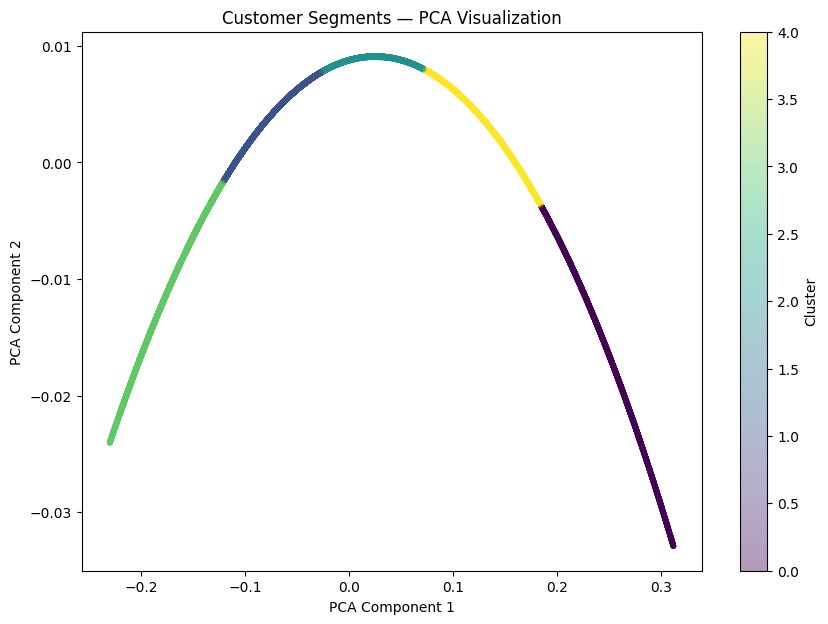

In [52]:
# PCA on normalized data
pca = PCA(n_components=2)
df_1_pca = pca.fit_transform(df_1_normal)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_1_pca[:, 0], 
    df_1_pca[:, 1],
    c=df_1['cluster'],
    # cmap='tab10',
    alpha=0.4,
    s=10
)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments — PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [57]:
fig = px.scatter(
                    df_1,
                    x='price_usd',
                    y='rating',
                    color='cluster',                
                    color_continuous_scale='bluered',
                    opacity=0.6,
                    title='Clusters — Price vs Rating'
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(
                xaxis_title='Price (USD)',
                yaxis_title='Rating',
                width=800,
                height=600,
                template='plotly_white',
                title_x = 0.5,
                coloraxis_colorbar=dict(title='Cluster')
)
fig.show()

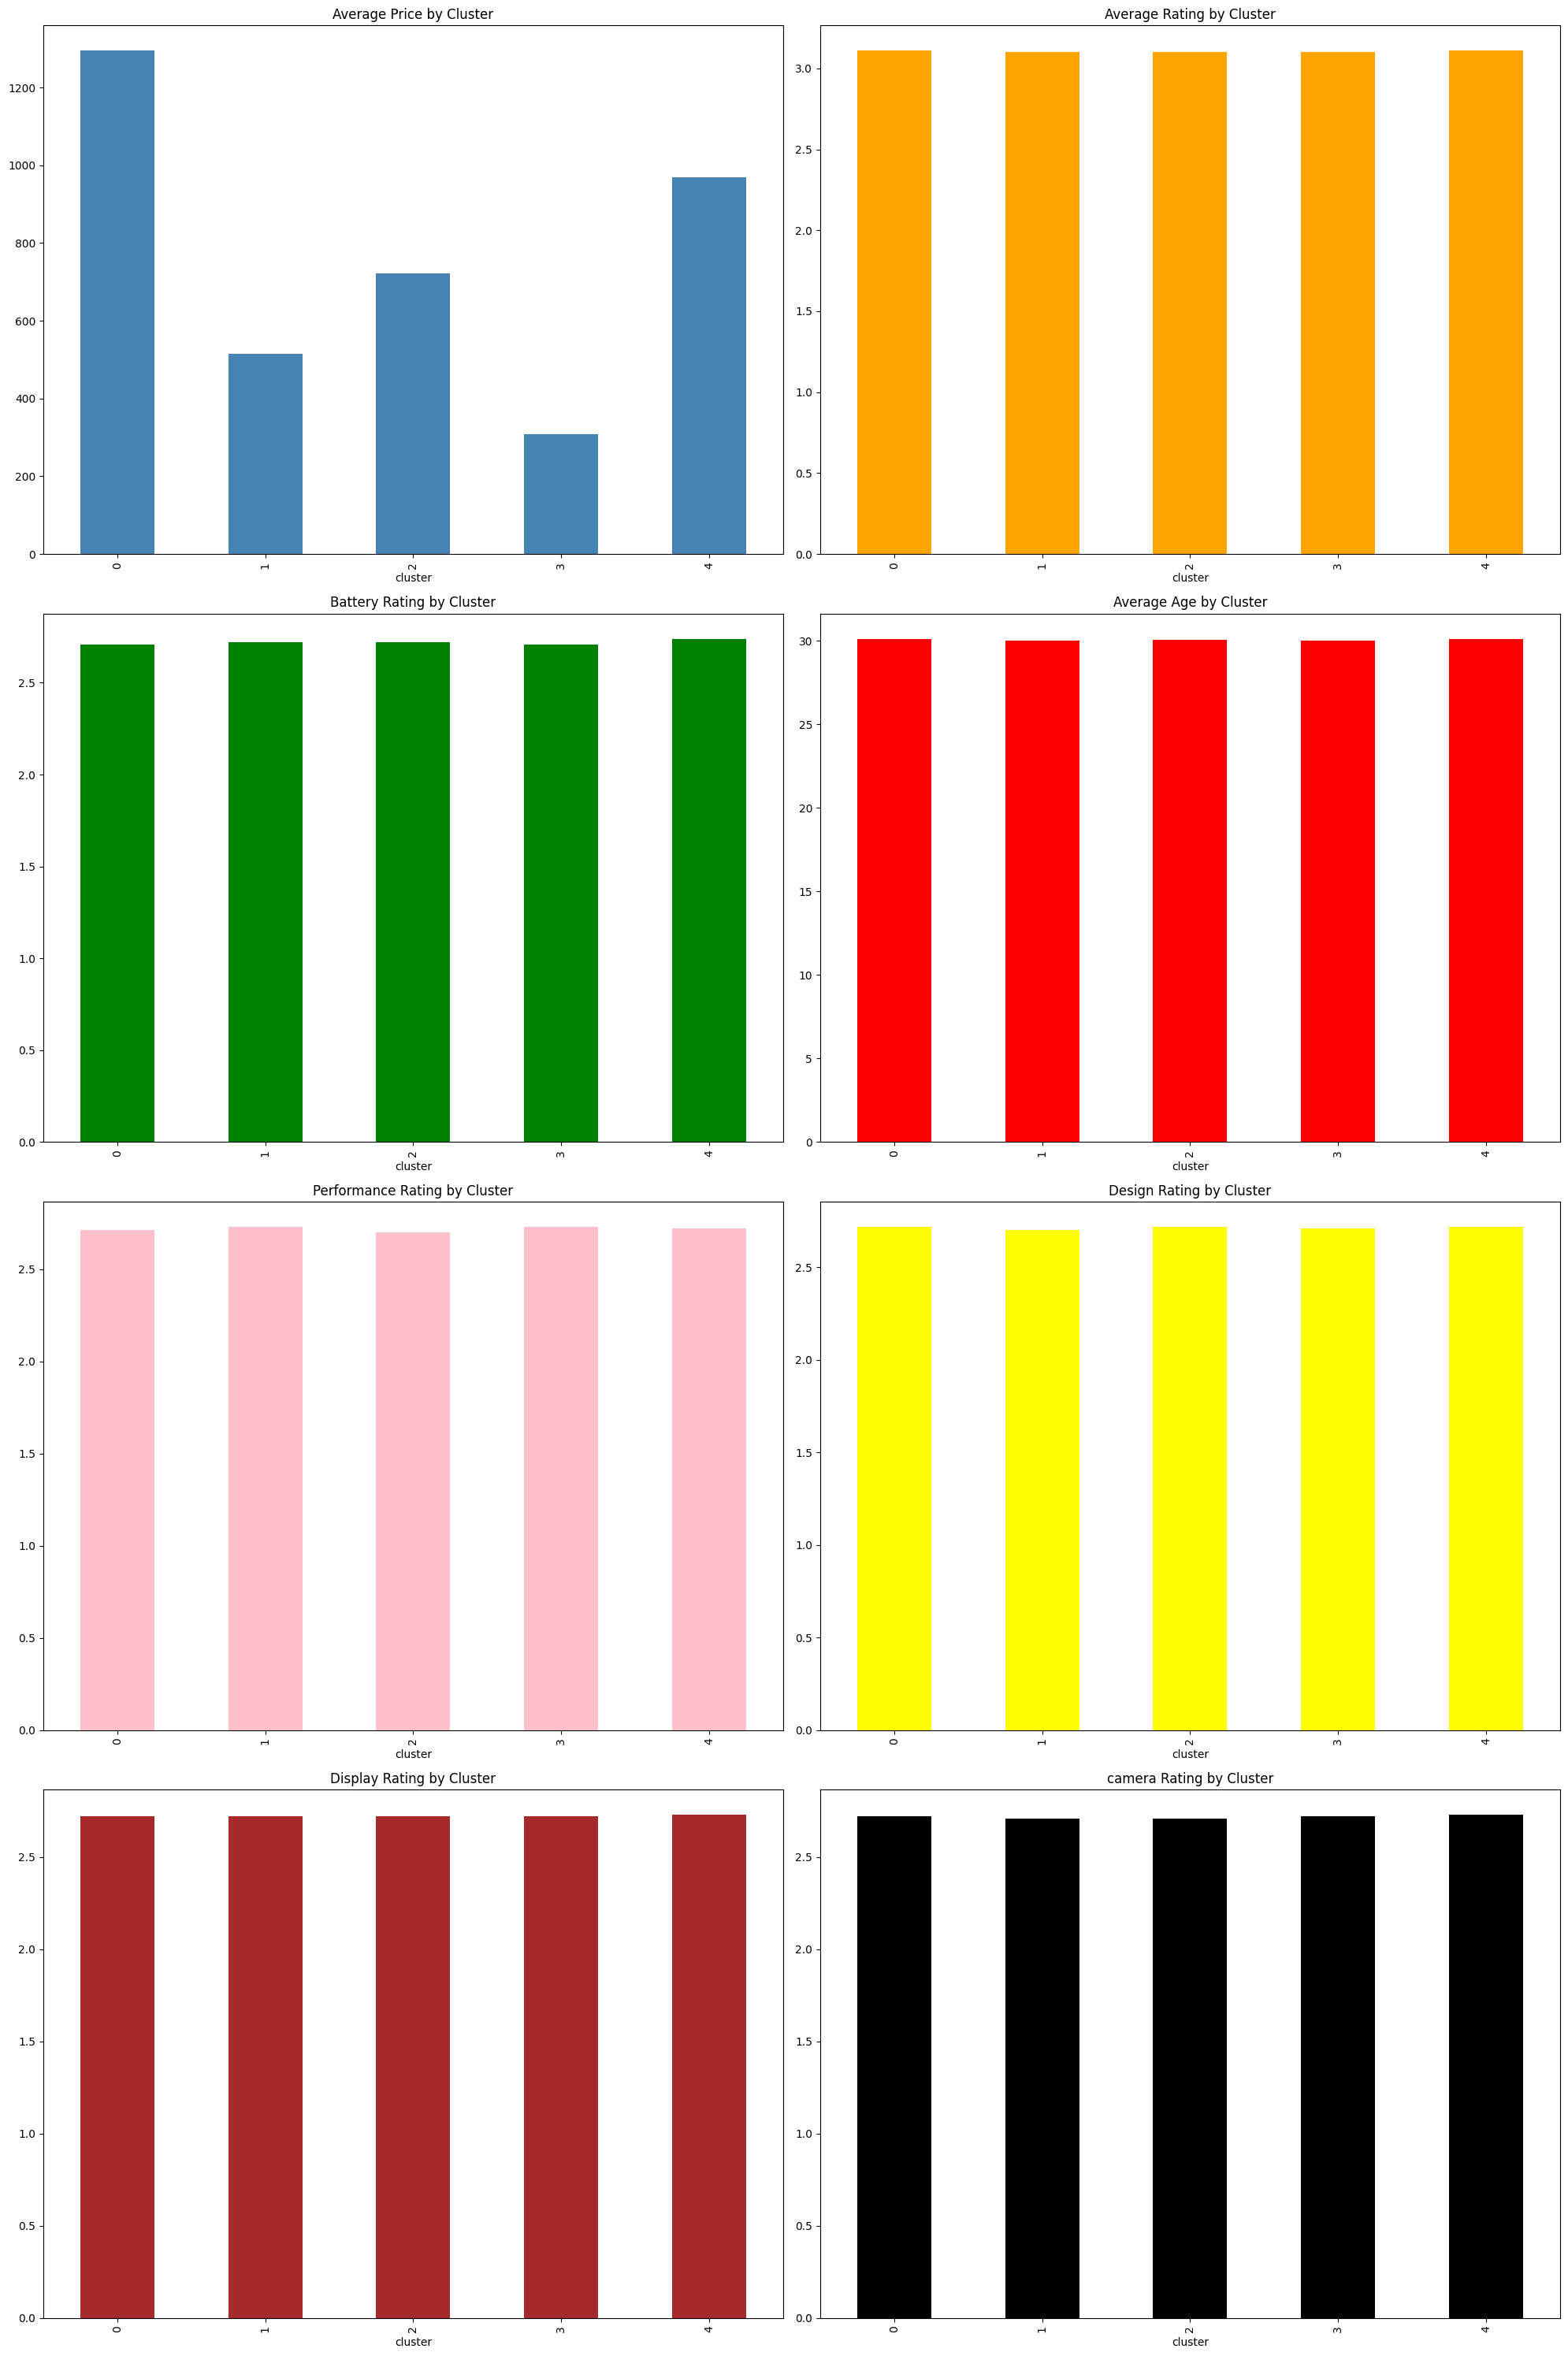

In [58]:
fig, axes = plt.subplots(4, 2, figsize=(20, 30))

profile_1['price_usd'].plot(kind='bar', ax=axes[0,0], 
    color='steelblue', title='Average Price by Cluster')

profile_1['rating'].plot(kind='bar', ax=axes[0,1], 
    color='orange', title='Average Rating by Cluster')

profile_1['battery_life_rating'].plot(kind='bar', ax=axes[1,0], 
    color='green', title='Battery Rating by Cluster')

profile_1['age'].plot(kind='bar', ax=axes[1,1], 
    color='red', title='Average Age by Cluster')

profile_1['performance_rating'].plot(kind='bar', ax=axes[2,0], 
    color='pink', title='Performance Rating by Cluster')

profile_1['design_rating'].plot(kind='bar', ax=axes[2,1], 
    color='yellow', title='Design Rating by Cluster')

profile_1['display_rating'].plot(kind='bar', ax=axes[3,0], 
    color='brown', title='Display Rating by Cluster')

profile_1['camera_rating'].plot(kind='bar', ax=axes[3,1], 
    color='black', title='camera Rating by Cluster')


plt.tight_layout()
plt.show()